In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.style.use("ggplot")

csv_file_path = "NF-UQ-NIDS.csv"
df = pd.read_csv(csv_file_path)
print("Dataset laoded successfully")

Dataset laoded successfully


In [10]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")

for i, col in enumerate(df.columns, 1) : 
    print(f"{i:2d}. {col}")

print("\nData Types")
print(df.dtypes)

Dataset Shape
Rows    : 11,994,893
Columns : 15

Column Names
 1. IPV4_SRC_ADDR
 2. L4_SRC_PORT
 3. IPV4_DST_ADDR
 4. L4_DST_PORT
 5. PROTOCOL
 6. L7_PROTO
 7. IN_BYTES
 8. OUT_BYTES
 9. IN_PKTS
10. OUT_PKTS
11. TCP_FLAGS
12. FLOW_DURATION_MILLISECONDS
13. Label
14. Attack
15. Dataset

Data Types
IPV4_SRC_ADDR                     str
L4_SRC_PORT                     int64
IPV4_DST_ADDR                     str
L4_DST_PORT                     int64
PROTOCOL                        int64
L7_PROTO                      float64
IN_BYTES                        int64
OUT_BYTES                       int64
IN_PKTS                         int64
OUT_PKTS                        int64
TCP_FLAGS                       int64
FLOW_DURATION_MILLISECONDS      int64
Label                           int64
Attack                            str
Dataset                           str
dtype: object


In [11]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state = 42))

,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label,Attack,Dataset
0,149.171.126.0,62073,59.166.0.5,56082,6,0.0,9672,416,11,8,25,15,0,Benign,NF-UNSW-NB15
1,149.171.126.2,32284,59.166.0.5,1526,6,0.0,1776,104,6,2,25,0,0,Benign,NF-UNSW-NB15
2,149.171.126.0,21,59.166.0.1,21971,6,1.0,1842,1236,26,22,25,1111,0,Benign,NF-UNSW-NB15
3,59.166.0.1,23800,149.171.126.0,46893,6,0.0,528,8824,10,12,27,124,0,Benign,NF-UNSW-NB15
4,59.166.0.5,63062,149.171.126.2,21,6,1.0,1786,2340,32,34,25,1459,0,Benign,NF-UNSW-NB15


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label,Attack,Dataset
11994888,192.168.100.46,80,192.168.100.5,80,6,7.000,2330065,0,2523,0,0,4263037,0,Benign,NF-BoT-IoT
11994889,192.168.100.5,0,192.168.100.3,0,6,0.000,1054423,0,1513,0,0,4263062,0,Benign,NF-BoT-IoT
11994890,192.168.100.7,365,192.168.100.3,565,17,0.000,62422,0,1357,0,0,4263062,0,Benign,NF-BoT-IoT
11994891,192.168.100.3,50850,13.54.166.67,8883,6,222.178,11300,1664,32,32,24,4264935,0,Benign,NF-BoT-IoT
11994892,192.168.100.6,49160,192.168.100.149,4444,6,0.000,40102320,37280,763,590,24,4270068,1,Theft,NF-BoT-IoT


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label,Attack,Dataset
4817595,172.31.67.17,55637,172.31.0.2,53,17,0.000,122,193,2,2,0,0,0,Benign,NF-CSE-CIC-IDS2018
5763255,172.31.67.19,55604,52.84.14.70,443,6,91.178,942,6219,10,10,218,4294829,0,Benign,NF-CSE-CIC-IDS2018
8230100,172.31.64.19,50884,151.101.34.109,443,6,0.000,2938,779,9,9,218,4294565,0,Benign,NF-CSE-CIC-IDS2018
9931989,18.219.5.43,51661,172.31.69.25,80,6,0.000,232,0,5,0,222,0,1,DDoS,NF-CSE-CIC-IDS2018
5517214,172.31.64.119,49981,104.152.169.38,443,6,0.000,332,403,6,7,29,4291830,0,Benign,NF-CSE-CIC-IDS2018


In [14]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(4)
})

missing = missing.sort_values("Missing Count", ascending=False)

display(missing)

,Missing Count,Missing %
IPV4_SRC_ADDR,0,0.0
L4_SRC_PORT,0,0.0
IPV4_DST_ADDR,0,0.0
L4_DST_PORT,0,0.0
PROTOCOL,0,0.0
L7_PROTO,0,0.0
IN_BYTES,0,0.0
OUT_BYTES,0,0.0
IN_PKTS,0,0.0
OUT_PKTS,0,0.0


In [16]:
duplicates = df.duplicated()

print("=" * 50)
print("Duplicate Rows")
print("=" * 50)

print(f"Duplicate roes : {duplicates.sum():,}")
print(f"Percentage     : {duplicates.mean() * 100:.4f}%")

Duplicate Rows
Duplicate roes : 1,265,854
Percentage     : 10.5533%


Label Distribution


,Count,Percentage (%)
Label,,
0,9208048,76.77
1,2786845,23.23


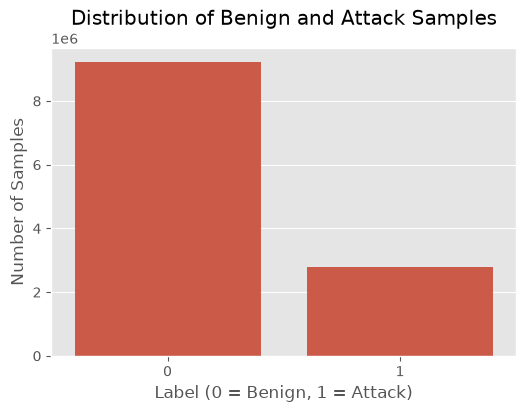

In [20]:
label_counts = df["Label"].value_counts().sort_index()
label_percent = (label_counts / len(df) * 100).round(2)

label_summary = pd.DataFrame({
    "Count" : label_counts, 
    "Percentage (%)" : label_percent
})

print("=" * 50)
print("Label Distribution")
print("=" * 50)
display(label_summary)

plt.figure(figsize = (6, 4))

sns.countplot(data = df, x = "Label")

plt.title("Distribution of Benign and Attack Samples")
plt.xlabel("Label (0 = Benign, 1 = Attack)")
plt.ylabel("Number of Samples")

plt.show()

Attack Category Distribution


,Count,Percentage (%)
Attack,,
Benign,9208048,76.766
DDoS,763285,6.363
Reconnaissance,482946,4.026
injection,468575,3.906
DoS,348962,2.909
Brute Force,291955,2.434
password,156299,1.303
xss,99944,0.833
Infilteration,62072,0.517


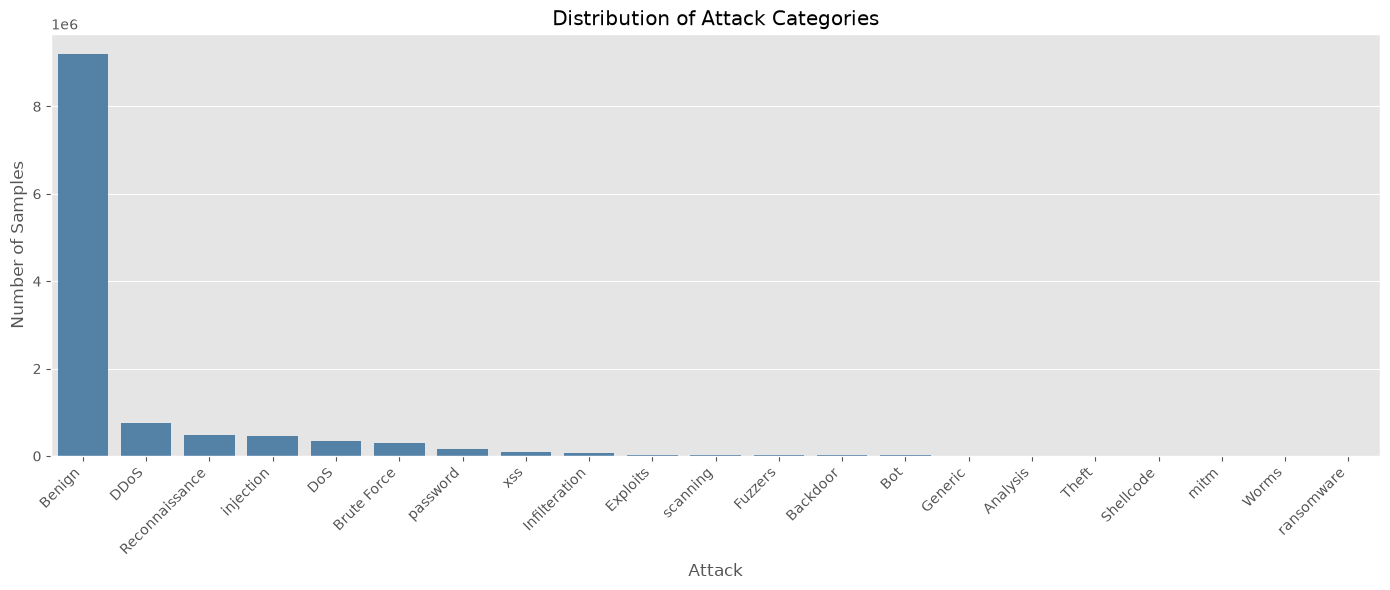

In [25]:
# Cell 7: Attack Category Distribution

attack_counts = df["Attack"].value_counts()

attack_percent = (attack_counts / len(df) * 100).round(3)

attack_summary = pd.DataFrame({
    "Count": attack_counts,
    "Percentage (%)": attack_percent
})

print("=" * 60)
print("Attack Category Distribution")
print("=" * 60)

display(attack_summary)

plt.figure(figsize=(14,6))

sns.barplot(
    x=attack_counts.index,
    y=attack_counts.values,
    color="steelblue"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Samples")
plt.title("Distribution of Attack Categories")

plt.tight_layout()
plt.show()

Original Dataset Distribution


,Count,Percentage (%)
Dataset,,
NF-CSE-CIC-IDS2018,8392401,69.97
NF-UNSW-NB15,1623118,13.53
NF-ToN-IoT,1379274,11.50
NF-BoT-IoT,600100,5.00


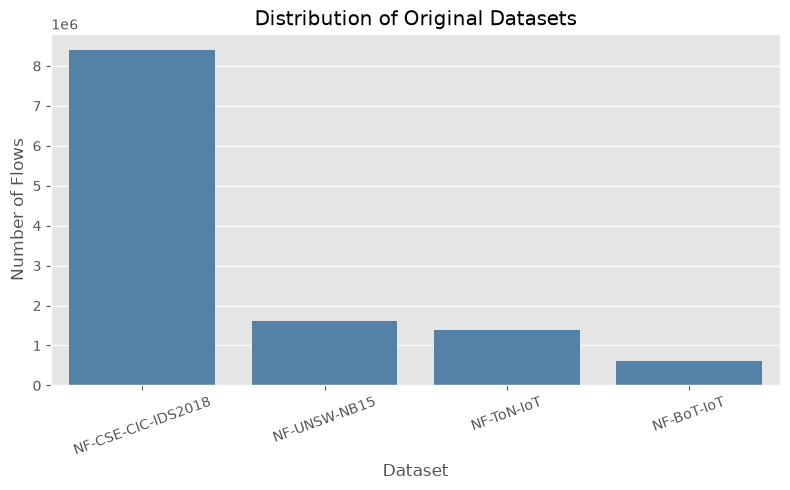

In [26]:
dataset_counts = df["Dataset"].value_counts()
dataset_percent = (dataset_counts / len(df) * 100).round(2)
dataset_summary = pd.DataFrame({
    "Count" : dataset_counts, 
    "Percentage (%)" : dataset_percent
})

print("=" * 60)
print("Original Dataset Distribution")
print("=" * 60)

display(dataset_summary)

plt.figure(figsize = (8, 5))

sns.barplot(
    x = dataset_counts.index,
    y = dataset_counts.values, 
    color = "steelblue"
)

plt.title("Distribution of Original Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Flows")

plt.xticks(rotation = 20)

plt.tight_layout()
plt.show()

In [27]:
numeric_df = df.select_dtypes(include = ["int64", "float64"])
summary = numeric_df.describe().T
summary["Range"] = summary["max"] - summary["min"]

display(summary)

,count,mean,std,min,25%,50%,75%,max,Range
L4_SRC_PORT,11994893.0,4.124519e+04,2.108654e+04,0.0,32994.0,50610.0,55817.0,65535.0,65535.0
L4_DST_PORT,11994893.0,8.964758e+03,1.772082e+04,0.0,53.0,443.0,3389.0,65535.0,65535.0
PROTOCOL,11994893.0,8.661742e+00,6.404263e+00,0.0,6.0,6.0,6.0,255.0,255.0
L7_PROTO,11994893.0,1.932050e+01,3.504857e+01,0.0,0.0,0.0,7.0,251.0,251.0
IN_BYTES,11994893.0,3.983727e+03,1.662256e+05,0.0,68.0,232.0,1440.0,228223480.0,228223480.0
OUT_BYTES,11994893.0,9.489449e+03,2.933544e+05,0.0,0.0,156.0,1873.0,243219688.0,243219688.0
IN_PKTS,11994893.0,3.562578e+01,1.901997e+03,0.0,1.0,4.0,9.0,1221043.0,1221043.0
OUT_PKTS,11994893.0,1.251652e+01,5.192708e+02,0.0,0.0,2.0,7.0,1349068.0,1349068.0
TCP_FLAGS,11994893.0,5.095628e+01,7.733605e+01,0.0,2.0,24.0,27.0,223.0,223.0
FLOW_DURATION_MILLISECONDS,11994893.0,2.163429e+06,2.142507e+06,0.0,0.0,4178245.0,4294858.0,4294967.0,4294967.0


In [28]:
columns_to_check = [ 
    "PROTOCOL",
    "L7_PROTO",
    "TCP_FLAGS",
    "Dataset",
    "Attack",
    "Label"
]

for col in columns_to_check : 
    print("=" * 60)
    print(col)
    print(f"Unique values : {df[col].nunique()}")
    print(df[col].unique()[:30])
    print()

PROTOCOL
Unique values : 256
[  6  17   1 132  89   2   0   3   4   5   7   8   9  10  11  12  13  14
  15  16  18  19  20  21  22  23  24  25  26  27]

L7_PROTO
Unique values : 465
[  0.     1.     5.     7.     3.     4.    92.    11.    36.    81.
  37.    47.36 175.     2.68 127.    84.   100.    10.    77.    91.
  40.    18.    85.    50.    17.    20.   167.36 114.36 115.   131.7 ]

TCP_FLAGS
Unique values : 49
[ 25  27   0  19  26  20  30  18   2  22  17  16  23  31  24  29  28  21
   6   4 215 214 211 219 194 223 218 222 152  61]

Dataset
Unique values : 4
<StringArray>
['NF-UNSW-NB15', 'NF-ToN-IoT', 'NF-CSE-CIC-IDS2018', 'NF-BoT-IoT']
Length: 4, dtype: str

Attack
Unique values : 21
<StringArray>
[        'Benign',       'Exploits', 'Reconnaissance',            'DoS',
        'Generic',      'Shellcode',       'Backdoor',        'Fuzzers',
          'Worms',       'Analysis',      'injection',           'DDoS',
       'scanning',       'password',           'mitm',           

Top 15 Network Protocols


,Count,Percentage (%)
PROTOCOL,,
6,9151668,76.296
17,2769768,23.091
1,43538,0.363
2,11994,0.100
58,5602,0.047
89,1772,0.015
47,93,0.001
33,77,0.001
41,77,0.001


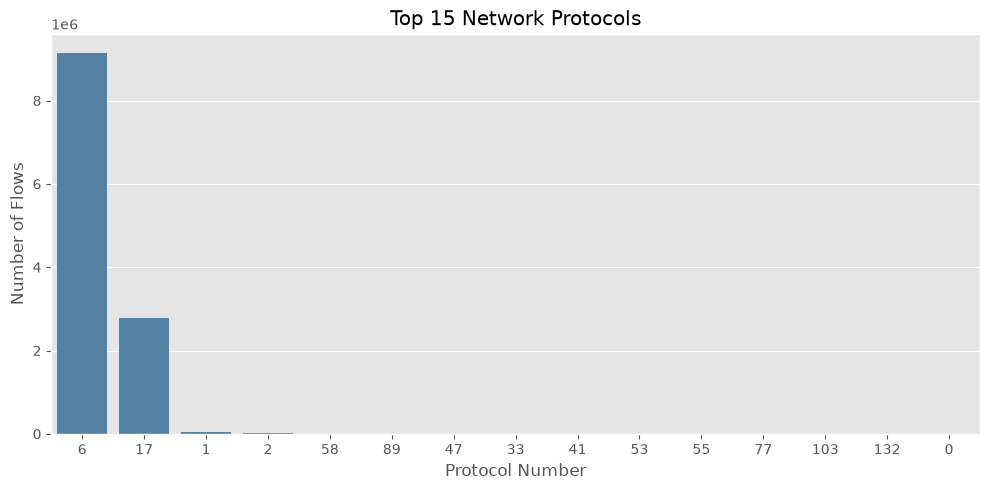

In [32]:
protocol_counts = (
    df["PROTOCOL"]
    .value_counts()
    .sort_values(ascending=False)
)

protocol_summary = pd.DataFrame({
    "Count" : protocol_counts,
    "Percentage (%)" : (protocol_counts / len(df) * 100).round(3)
})

print("=" * 60)
print("Top 15 Network Protocols")
print("=" * 60)

display(protocol_summary.head(15))

plt.figure(figsize=(10, 5))

sns.barplot(
    x = protocol_summary.head(15).index.astype(str),
    y = protocol_summary.head(15)["Count"],
    color = "steelblue"
)

plt.xlabel("Protocol Number")
plt.ylabel("Number of Flows")
plt.title("Top 15 Network Protocols")

plt.tight_layout()
plt.show()

Top 20 Desitnation Ports


,Count,Percentage (%)
L4_DST_PORT,,
53,2427941,20.241
80,2123023,17.699
443,1636491,13.643
3389,1305078,10.880
445,362197,3.020
21,340035,2.835
22,149208,1.244
5190,94708,0.790
6881,89930,0.750


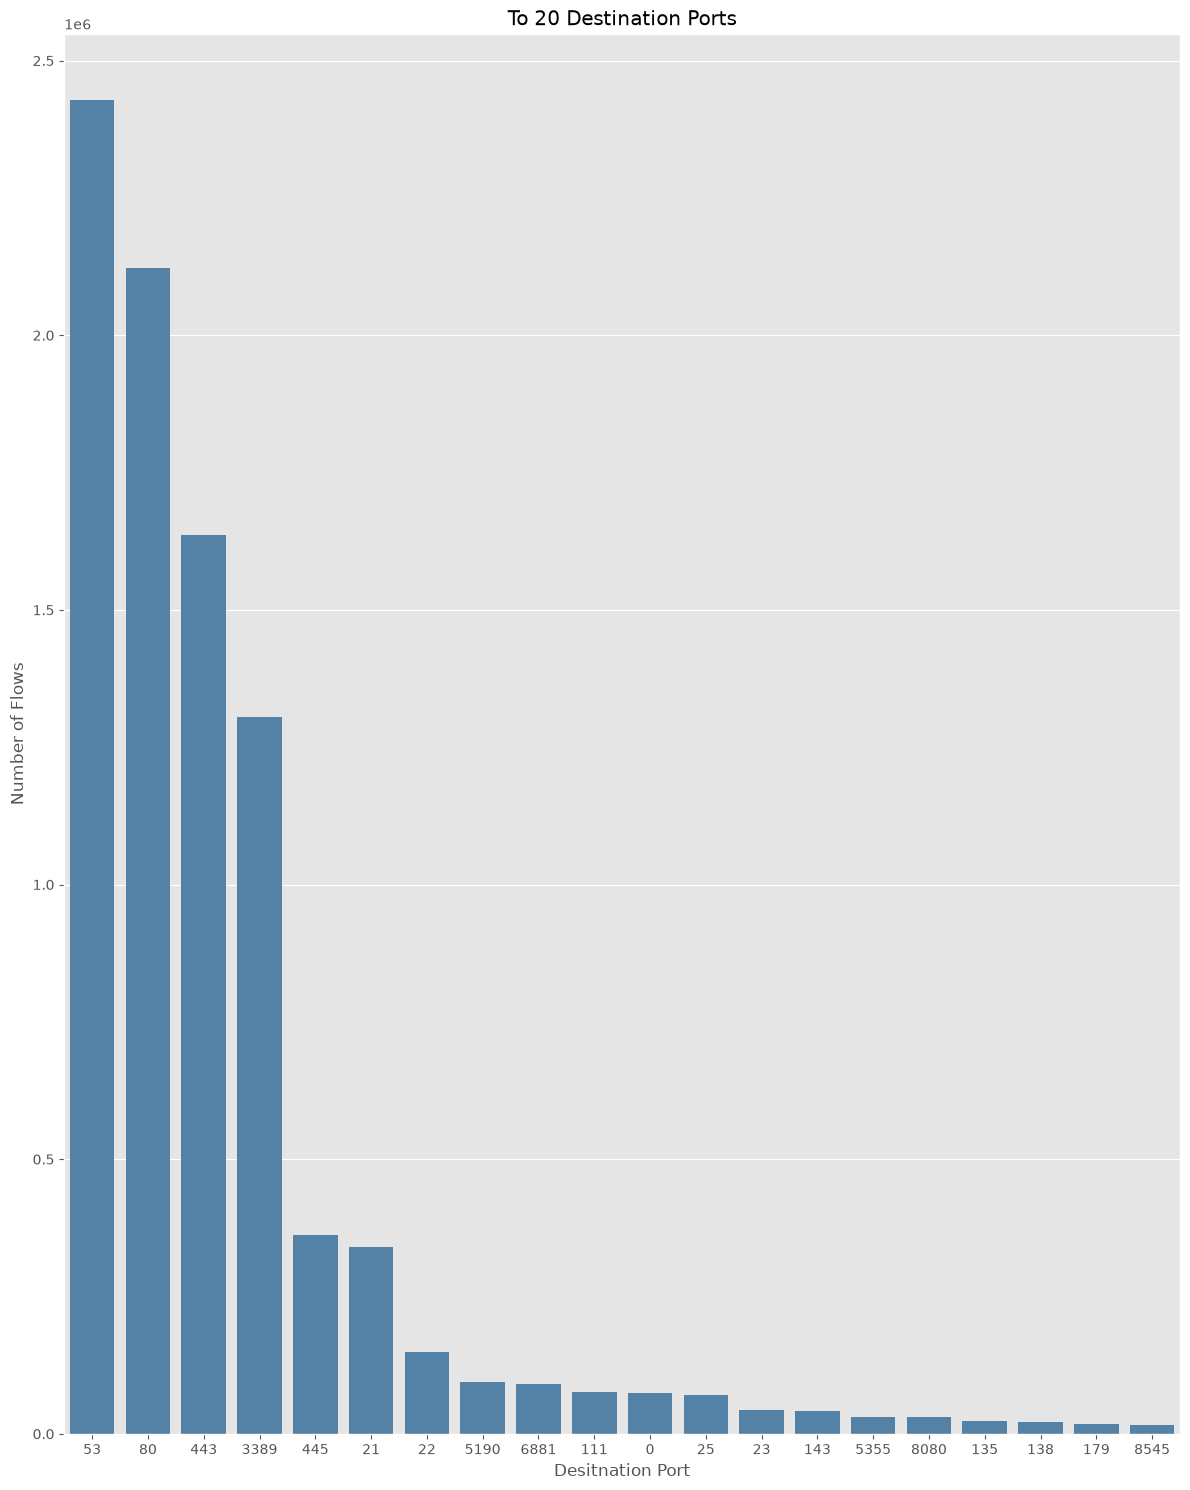

In [35]:
dst_port_counts = df["L4_DST_PORT"].value_counts().head(20)
dst_port_summary = pd.DataFrame({
    "Count" : dst_port_counts,
    "Percentage (%)" : (dst_port_counts / len(df) * 100).round(3)
})

print("=" * 60)
print("Top 20 Desitnation Ports")
print("=" * 60)

display(dst_port_summary)

plt.figure(figsize=(12, 15))

sns.barplot(
    x = dst_port_summary.index.astype(str),
    y = dst_port_summary["Count"],
    color = "steelblue"
)

plt.title("To 20 Destination Ports")
plt.xlabel("Desitnation Port")
plt.ylabel("Number of Flows")

plt.tight_layout()
plt.show()

,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,FLOW_DURATION_MILLISECONDS
0,9672,416,11,8,15
1,1776,104,6,2,0
2,1842,1236,26,22,1111
3,528,8824,10,12,124
4,1786,2340,32,34,1459
...,...,...,...,...,...
11994888,2330065,0,2523,0,4263037
11994889,1054423,0,1513,0,4263062
11994890,62422,0,1357,0,4263062
11994891,11300,1664,32,32,4264935


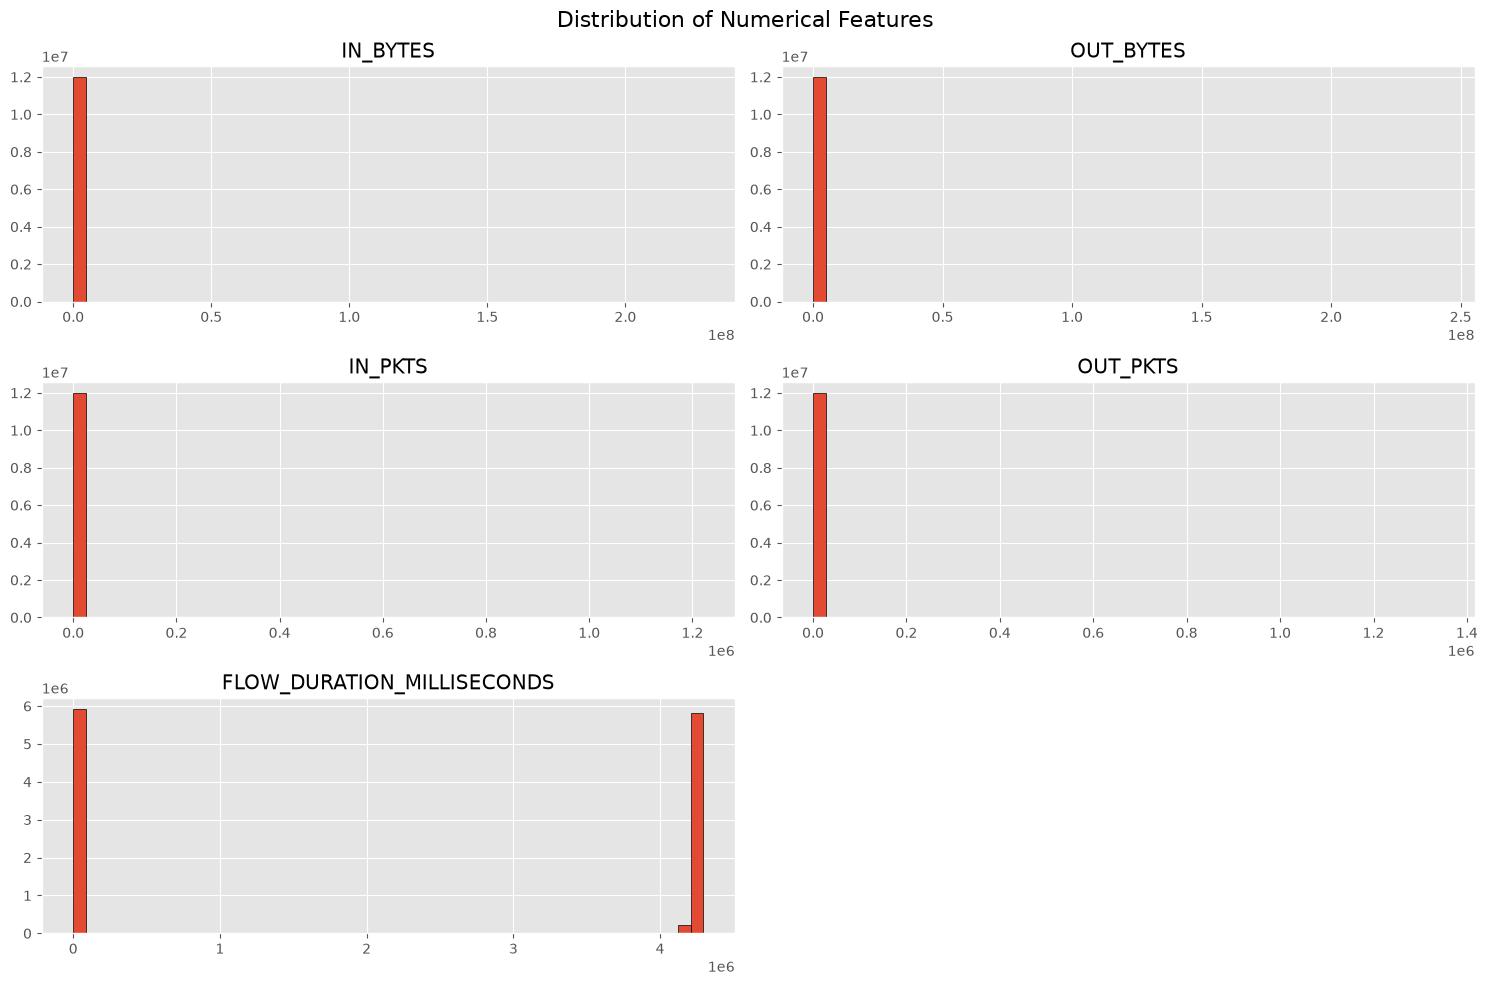

In [38]:
# Cell 13: Histograms of Numerical Features

numeric_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS"
]

df[numeric_features].hist(
    bins=50,
    figsize=(15, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

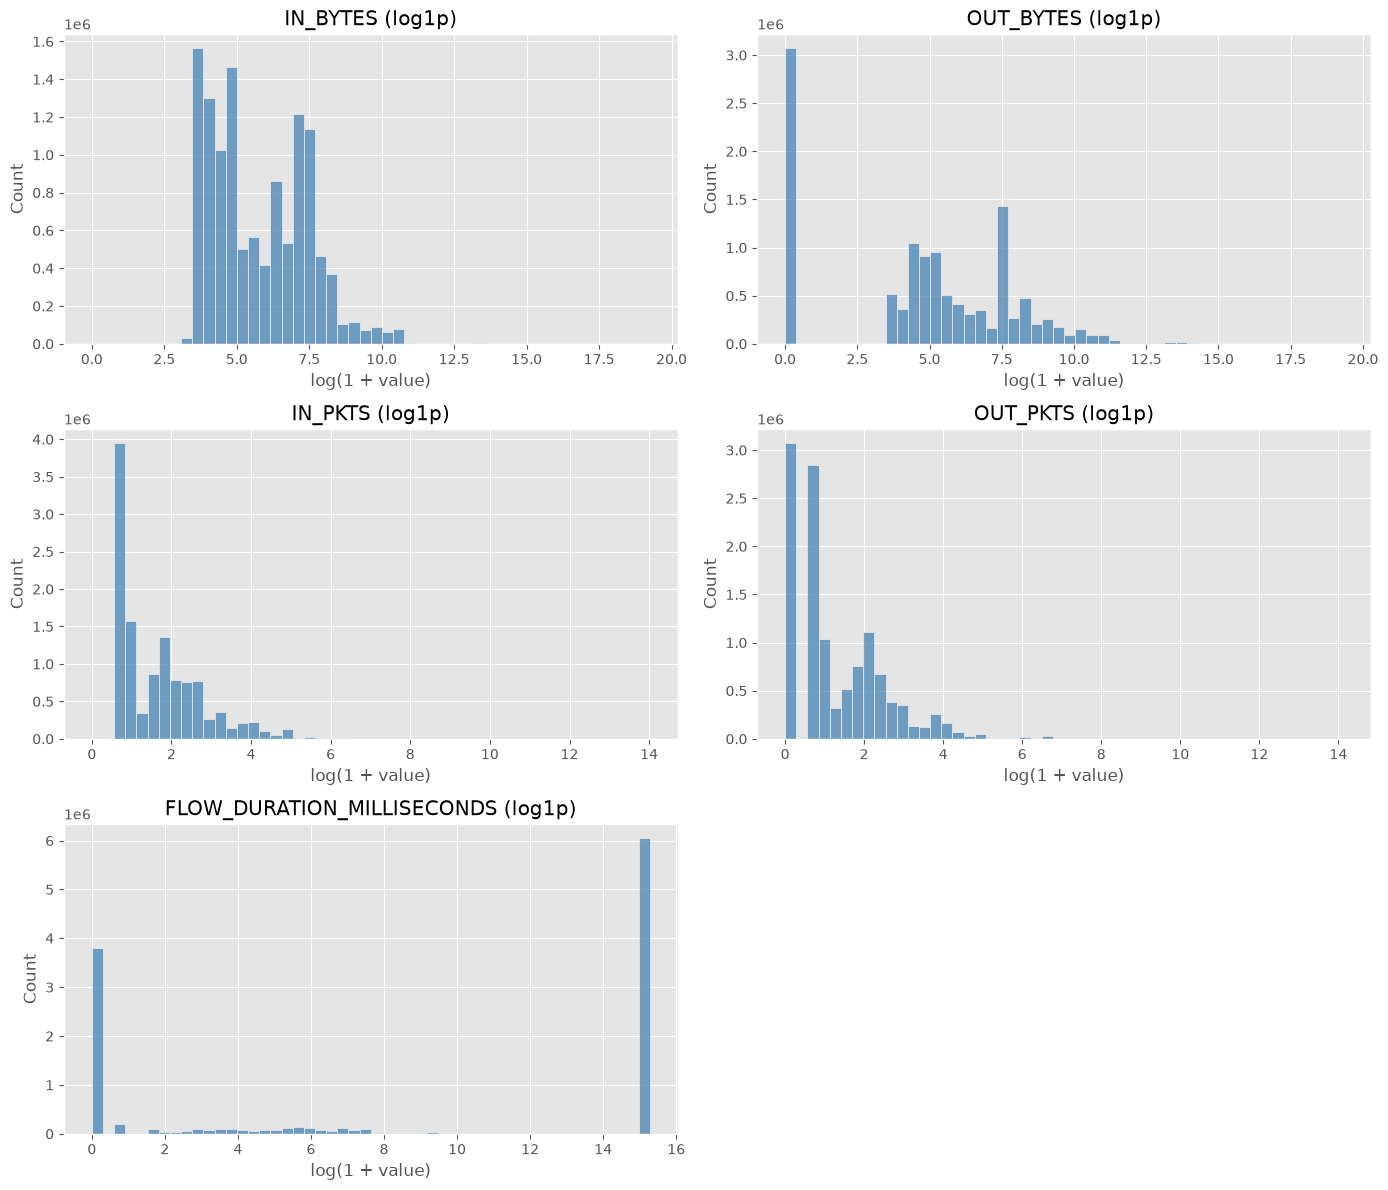

In [39]:
# Cell 14: Log-Scale Histograms

numeric_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        np.log1p(df[feature]),
        bins=50,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"{feature} (log1p)")
    axes[i].set_xlabel("log(1 + value)")

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

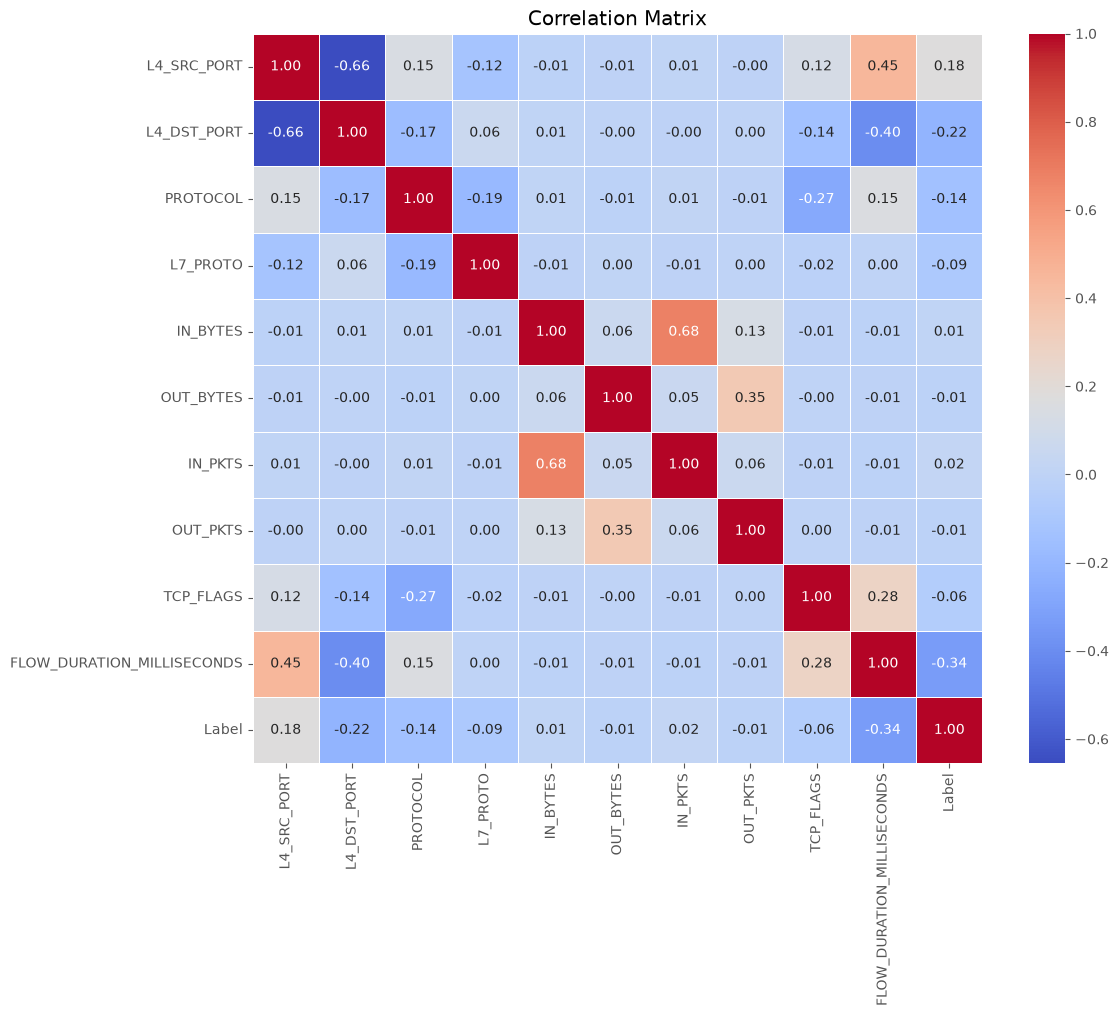

In [43]:
numeric_df = df.select_dtypes(include = ["int64", "float64"])
corr = numeric_df.corr(numeric_only = True)
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr, 
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    square = True,
    linewidths = 0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

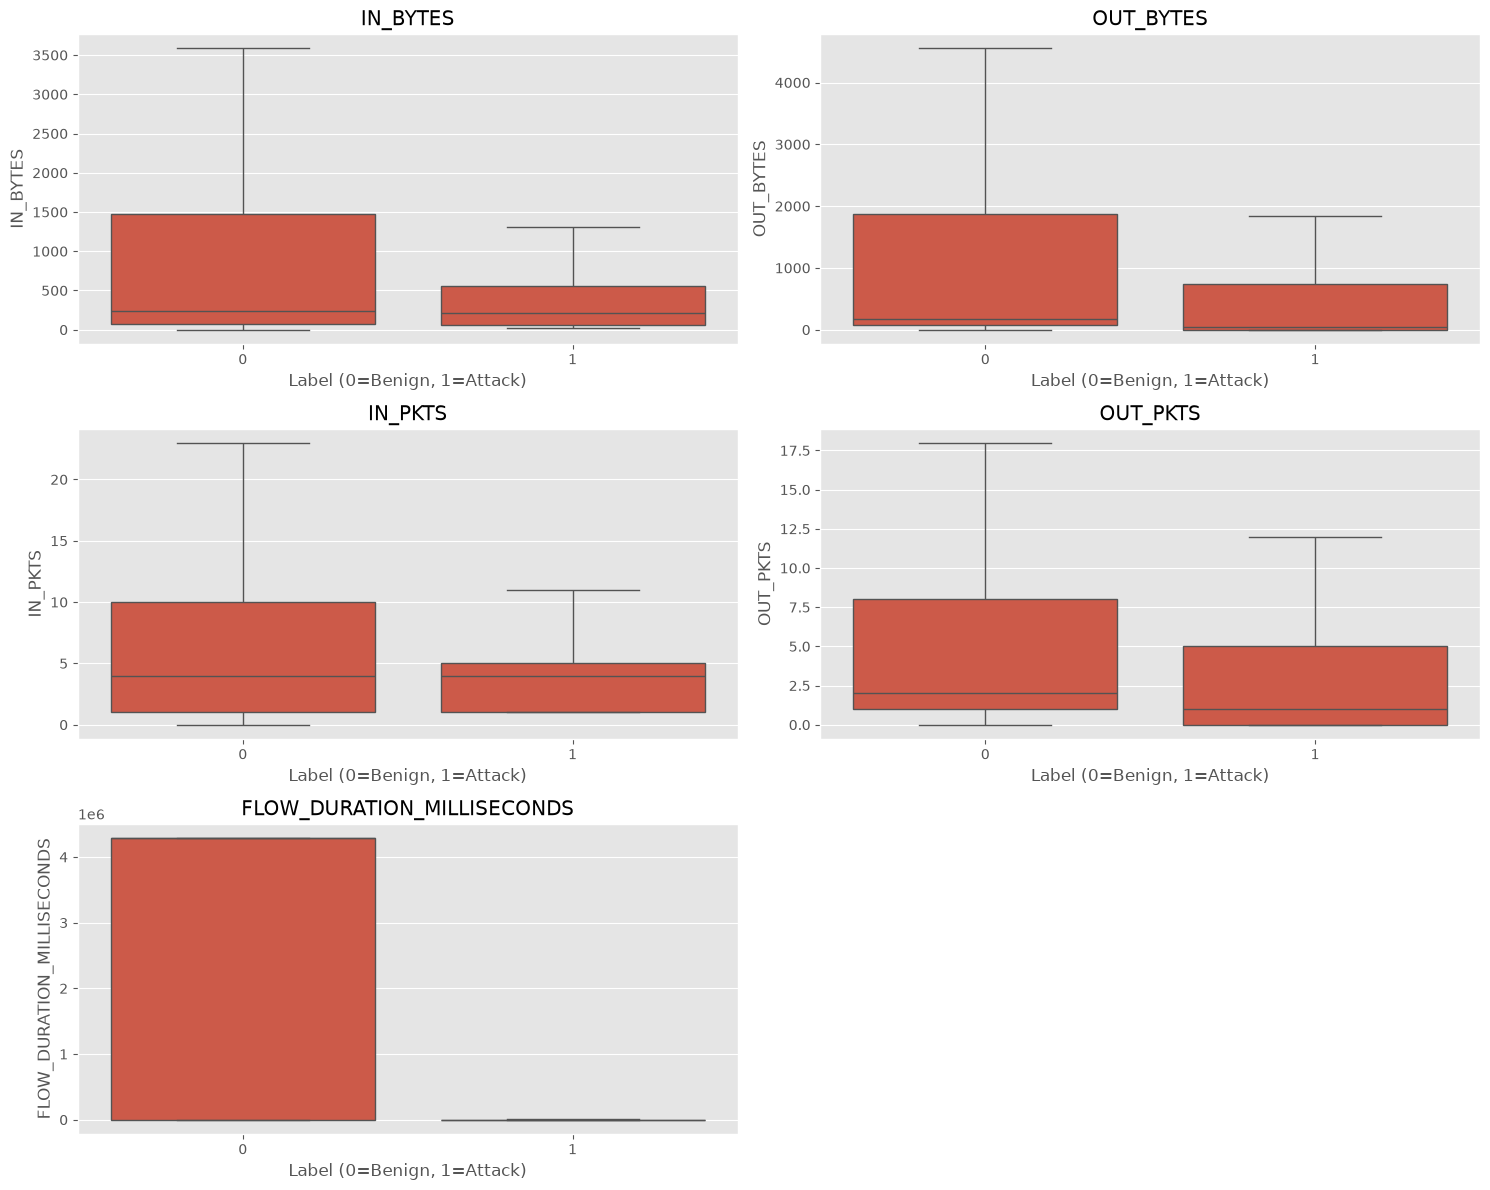

In [46]:
# Cell 16: Numerical Features by Label

features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x="Label",
        y=feature,
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Label (0=Benign, 1=Attack)")

# RemoveS unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Top TCP Flag Values


,Count,Percentage (%)
TCP_FLAGS,,
0,2844423,23.714
27,2713069,22.619
20,867906,7.236
222,782733,6.526
219,752537,6.274
2,599136,4.995
24,583009,4.860
30,489300,4.079
22,447049,3.727


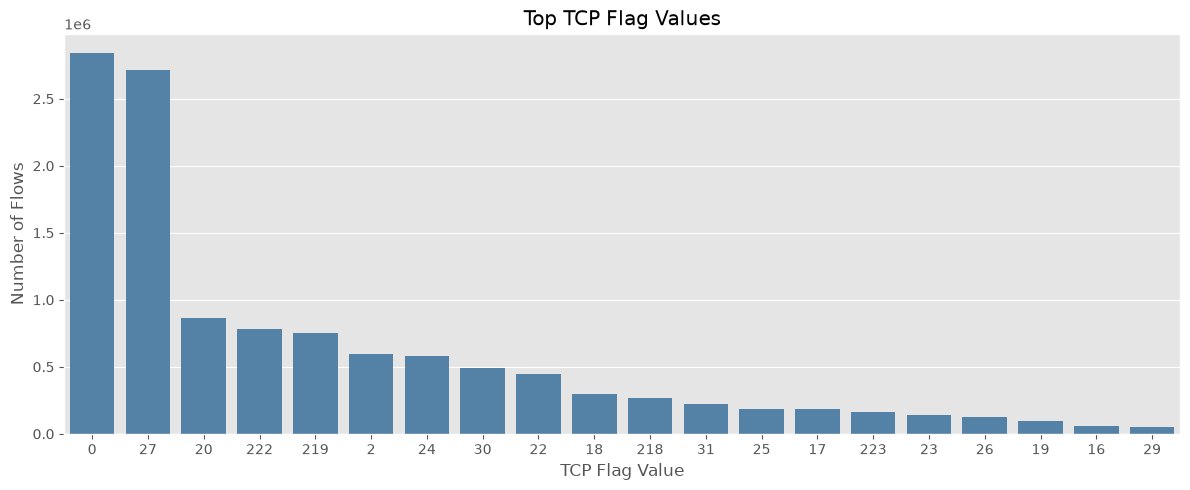

In [47]:
# Cell 17: TCP Flags Distribution

flags = df["TCP_FLAGS"].value_counts().head(20)

summary = pd.DataFrame({
    "Count": flags,
    "Percentage (%)": (flags / len(df) * 100).round(3)
})

print("=" * 60)
print("Top TCP Flag Values")
print("=" * 60)

display(summary)

plt.figure(figsize=(12,5))

sns.barplot(
    x=summary.index.astype(str),
    y=summary["Count"],
    color="steelblue"
)

plt.title("Top TCP Flag Values")
plt.xlabel("TCP Flag Value")
plt.ylabel("Number of Flows")

plt.tight_layout()

plt.show()

In [48]:
# Cell 18: IP Address Analysis

print("=" * 60)
print("IP Address Analysis")
print("=" * 60)

print(f"Unique Source IPs      : {df['IPV4_SRC_ADDR'].nunique():,}")
print(f"Unique Destination IPs : {df['IPV4_DST_ADDR'].nunique():,}")

print("\nTop 10 Source IPs")
display(df["IPV4_SRC_ADDR"].value_counts().head(10))

print("\nTop 10 Destination IPs")
display(df["IPV4_DST_ADDR"].value_counts().head(10))

IP Address Analysis
Unique Source IPs      : 75,630
Unique Destination IPs : 27,826

Top 10 Source IPs


IPV4_SRC_ADDR
172.31.69.25       840864
192.168.1.31       269925
192.168.1.30       268910
192.168.1.36       244364
192.168.1.33       195761
18.221.219.4       193360
192.168.100.148    171096
59.166.0.5         153762
59.166.0.1         153439
59.166.0.4         153404
Name: count, dtype: int64


Top 10 Destination IPs


IPV4_DST_ADDR
172.31.0.2         2045759
172.31.69.25        940292
192.168.1.190       287600
192.168.100.3       272805
192.168.1.184       240988
169.254.169.254     238785
18.221.219.4        193360
192.168.1.195       191669
192.168.1.152       190226
149.171.126.1       153450
Name: count, dtype: int64